# Session 7, Notebook 1: SMM with One Parameter

**Course:** Deep Learning for Solving Dynamic Models, University of Padova, 23-24 September 2026
**Session:** Day 2, 10:05-11:00, Structural estimation via the simulated method of moments
**Slides:** `07_Structural_Estimation_SMM.pdf`
**Author:** Simon Scheidegger (HEC, University of Lausanne)

In [1]:
RUN_MODE = "teaching"  # one of: "smoke", "teaching", "production"
SEED = 0

Estimate the persistence $\varrho$ of productivity in the stochastic Brock-Mirman model of
Session 2 by the simulated method of moments, with the model's solution replaced by a network that
takes $\varrho$ as an input.

The steps, each one section:

| Section | Step |
|:--|:--|
| 1 | The data: one sample from the model at $\varrho = 0.90$, solved by the reference method |
| 2 | The surrogate: a policy network with $\varrho$ as a pseudo-state, trained on the Euler equation |
| 3 | Its accuracy, measured against the reference solution at several $\varrho$ |
| 4 | Simulated moments as a function of $\varrho$ under common random numbers |
| 5 | The SMM criterion and the estimate |

The reference solver (`brock_mirman_reference.py`, endogenous grid method) takes about a second
per parameter value. That is the cost the surrogate removes from the estimation loop: once
trained, a candidate $\varrho$ costs one simulation, and the loop runs on the fly.

In [2]:
# ----------------------------------------------------------------
# Imports, presets, plot style, the reference solver
# ----------------------------------------------------------------
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from scipy.optimize import minimize_scalar
import torch
import torch.nn as nn

sys.path.insert(0, "..")
import brock_mirman_reference as bm

torch.set_num_threads(2)
torch.manual_seed(SEED)
np.random.seed(SEED)

rcParams.update({"figure.dpi": 120, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
                 "legend.fontsize": 10, "font.family": "serif", "mathtext.fontset": "cm",
                 "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
C_REF, C_SUR, C_DATA = "#264653", "#e76f51", "#2a9d8f"

FIG_DIR   = Path("..") / ".." / "slides" / "figures"
SAVE_FIGS = (RUN_MODE == "teaching")
def savefig(fig, name):
    if SAVE_FIGS:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{name}.pdf", bbox_inches="tight")

N_STEPS  = {"smoke": 2000, "teaching": 12000, "production": 40000}[RUN_MODE]
T_DATA   = 500                                    # length of the observed sample
T_SIM    = {"smoke": 1000, "teaching": 2000, "production": 4000}[RUN_MODE]   # simulated sample per candidate
T_NOTEBOOK = time.perf_counter()
print(f"RUN_MODE = {RUN_MODE}: {N_STEPS} training steps, simulated samples of length {T_SIM}")

RUN_MODE = teaching: 12000 training steps, simulated samples of length 2000


---
## 1. The data

Model, with $\alpha = 0.36$, $\delta = 0.10$, $\sigma = 0.04$ and $\beta = 0.96$ fixed:

$$Y_t = z_t K_t^\alpha, \qquad K_{t+1} = (1-\delta)K_t + s_t Y_t, \qquad C_t = (1 - s_t) Y_t,
\qquad \log z_{t+1} = \varrho \log z_t + \sigma \varepsilon_{t+1}.$$

The "observed" sample is one path of length 500 from the model at $\varrho_{\rm true} = 0.90$, solved
by the reference method and simulated with its own shocks. Four moments summarize it: the standard
deviation and first autocorrelation of consumption growth, the first autocorrelation of log output,
and the mean investment share. The first three respond to persistence; the fourth is nearly flat in
$\varrho$ and is carried along as a check. A sample of 500 periods is short: the table also shows how
much each moment varies across 200 such samples, which is the sampling error the estimate inherits.

In [3]:
BETA, RHO_TRUE = 0.96, 0.90
RHO_LO, RHO_HI = 0.50, 0.99

t0 = time.perf_counter()
policy_true = bm.solve(BETA, RHO_TRUE)
print(f"one reference solve: {time.perf_counter()-t0:.2f} s ({policy_true.n_iter} iterations)")

Y_data, C_data, K_data = bm.simulate(policy_true, BETA, RHO_TRUE, T=T_DATA, seed=12)
m_data = bm.moments(Y_data, C_data, K_data)
USED = np.array([True, True, True, False])        # the fourth moment is diagnostic only

# How much do these moments vary from one 500-period sample to the next? 200 draws from the model.
m_draws = np.array([bm.moments(*bm.simulate(policy_true, BETA, RHO_TRUE, T=T_DATA, seed=s)) for s in range(200)])

print(f"\nobserved sample: T = {T_DATA}")
print(f"  {'moment':<20s} {'this sample':>12s} {'mean of 200':>12s} {'sd of 200':>10s}")
for name, v, mu, sd, u in zip(bm.MOMENT_NAMES, m_data, m_draws.mean(0), m_draws.std(0), USED):
    print(f"  {name:<20s} {v:>+12.5f} {mu:>+12.5f} {sd:>10.4f}   {'used' if u else 'diagnostic'}")

ee_ref = bm.euler_error(policy_true, BETA, RHO_TRUE, Y_data / K_data**bm.ALPHA, K_data)
print(f"\nreference solution on the sample: mean |Euler error| {np.abs(ee_ref).mean():.1e}, max {np.abs(ee_ref).max():.1e}")

one reference solve: 1.72 s (107 iterations)



observed sample: T = 500
  moment                this sample  mean of 200  sd of 200
  Std(dlog C)              +0.02049     +0.02040     0.0007   used
  Autocorr(dlog C)         +0.31090     +0.29041     0.0512   used
  Autocorr(log Y)          +0.94102     +0.94736     0.0127   used
  Mean savings rate        +0.25347     +0.25298     0.0013   diagnostic

reference solution on the sample: mean |Euler error| 3.0e-09, max 5.4e-09


---
## 2. The surrogate: a policy network with $\varrho$ as a pseudo-state

The network ($2 \times 128$, tanh) maps $(\log z_t, \log K_t, \varrho)$ to the consumption share of cash on hand
$m_t = Y_t + (1-\delta)K_t$ through a sigmoid, so $0 < C_t < m_t$ holds by construction and
$K_{t+1} = m_t - C_t$. It is trained on the relative Euler residual

$$e(z, K, \varrho) = 1 - \frac{1}{\beta\, C_t\, \mathbb{E}_t\!\left[\dfrac{1 - \delta + \alpha z_{t+1} K_{t+1}^{\alpha - 1}}{C_{t+1}}\right]},$$

with five Gauss-Hermite nodes for the expectation. Each batch mixes states drawn uniformly over a
box with states visited by simulating the current policy, so the network is accurate where the
estimation will evaluate it. Nothing about $\varrho$ is special: it is one more input, and the
Euler residual holds for every value of it.

In [4]:
Z_SD_MAX = bm.SIGMA / np.sqrt(1.0 - RHO_HI**2)          # widest ergodic sd of log z in the box
LOGZ_LIM = 4.0 * Z_SD_MAX
K_LO, K_HI = 0.5, 16.0
K_STAR = bm.steady_state(BETA)[0]
GH_X = torch.tensor(bm.GH_NODES, dtype=torch.float32); GH_W = torch.tensor(bm.GH_WEIGHTS, dtype=torch.float32)


class PolicyNet(nn.Module):
    """(log z, K, rho) -> consumption share of cash on hand, in (0, 1)."""
    def __init__(self, width=128):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(3, width), nn.Tanh(), nn.Linear(width, width), nn.Tanh(),
                                 nn.Linear(width, 1))
    def forward(self, logz, K, rho):
        x = torch.stack([logz / LOGZ_LIM, torch.log(K / K_STAR), (rho - 0.75) / 0.25], dim=-1)
        return torch.sigmoid(self.net(x)).squeeze(-1)


def step_economy(net, logz, K, rho):
    """One period under the network: returns C, K', and cash on hand m."""
    z = torch.exp(logz)
    m = z * K**bm.ALPHA + (1.0 - bm.DELTA) * K
    C = net(logz, K, rho) * m
    return C, m - C, m


def euler_residual(net, logz, K, rho):
    C, K1, _ = step_economy(net, logz, K, rho)
    rhs = torch.zeros_like(C)
    for x, w in zip(GH_X, GH_W):
        logz1 = rho * logz + bm.SIGMA * x
        C1, _, _ = step_economy(net, logz1, K1, rho)
        rhs = rhs + w * (1.0 - bm.DELTA + bm.ALPHA * torch.exp(logz1) * K1**(bm.ALPHA - 1.0)) / C1
    return 1.0 - 1.0 / (BETA * C * rhs)


def sample_box(n):
    return (torch.empty(n).uniform_(-LOGZ_LIM, LOGZ_LIM), torch.empty(n).uniform_(K_LO, K_HI),
            torch.empty(n).uniform_(RHO_LO, RHO_HI))


net = PolicyNet()
opt = torch.optim.Adam(net.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=N_STEPS, eta_min=1e-5)
BATCH = 256
logz_sim, K_sim, rho_sim = sample_box(BATCH // 2)        # persistent simulated states, one rho each

t0, losses = time.perf_counter(), []
for step in range(1, N_STEPS + 1):
    with torch.no_grad():                                 # advance the simulated half by one period
        _, K_sim, _ = step_economy(net, logz_sim, K_sim, rho_sim)
        logz_sim = rho_sim * logz_sim + bm.SIGMA * torch.randn(BATCH // 2)
        K_sim = K_sim.clamp(K_LO, K_HI)
    lb, kb, rb = sample_box(BATCH // 2)
    logz, K, rho = torch.cat([lb, logz_sim]), torch.cat([kb, K_sim]), torch.cat([rb, rho_sim])
    loss = torch.mean(euler_residual(net, logz, K, rho)**2)
    opt.zero_grad(); loss.backward(); opt.step(); sched.step()
    losses.append(loss.item())
    if step % (N_STEPS // 5) == 0:
        print(f"step {step:>6d}  mean squared Euler residual {np.mean(losses[-100:]):.2e}")
print(f"trained in {time.perf_counter()-t0:.0f} s; {sum(p.numel() for p in net.parameters())} parameters")


def surrogate_consumption(logz, K, rho):
    """numpy wrapper: consumption at states (arrays) under the trained network."""
    with torch.no_grad():
        C, _, _ = step_economy(net, *(torch.as_tensor(np.asarray(a, np.float32)) for a in np.broadcast_arrays(logz, K, rho)))
    return C.numpy()

step   2400  mean squared Euler residual 1.66e-06


step   4800  mean squared Euler residual 7.74e-07


step   7200  mean squared Euler residual 3.36e-07


step   9600  mean squared Euler residual 1.81e-07


step  12000  mean squared Euler residual 1.14e-07
trained in 151 s; 17153 parameters


---
## 3. Accuracy against the reference solution

Two numbers at each of four values of $\varrho$, on 2,000 states from the model's own ergodic
set: the surrogate's relative Euler error, and its consumption error against the reference solution,
$|C_{\rm net} - C_{\rm ref}| / C_{\rm ref}$. The second is the one that matters for estimation:
it says how far the simulated moments can be from the model's.

  rho  mean |Euler|  max |Euler|  mean |dC|/C  max |dC|/C
 0.50       1.6e-04      2.9e-04      8.3e-04     1.3e-03
 0.70       5.5e-05      1.4e-04      2.1e-04     4.9e-04
 0.90       1.1e-04      1.7e-04      5.7e-04     7.1e-04
 0.99       2.5e-04      4.6e-03      1.1e-03     2.1e-02


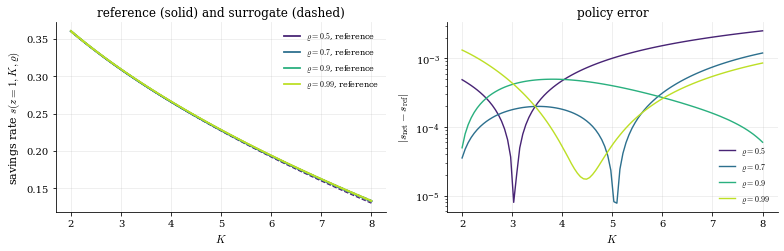

In [5]:
RHO_CHECK = [0.50, 0.70, 0.90, 0.99]
acc, refs = [], {}
for rho in RHO_CHECK:
    refs[rho] = pol = bm.solve(BETA, rho)
    Y, C, K = bm.simulate(pol, BETA, rho, T=2000, seed=7)
    logz = np.log(Y / K**bm.ALPHA)
    C_net = surrogate_consumption(logz, K, rho)
    ee = euler_residual(net, *(torch.as_tensor(np.asarray(a, np.float32)) for a in (logz, K, np.full_like(K, rho)))).detach().numpy()
    rel = np.abs(C_net - C) / C
    acc.append((rho, np.abs(ee).mean(), np.abs(ee).max(), rel.mean(), rel.max()))

print(f"{'rho':>5s} {'mean |Euler|':>13s} {'max |Euler|':>12s} {'mean |dC|/C':>12s} {'max |dC|/C':>11s}")
for r in acc:
    print(f"{r[0]:>5.2f} {r[1]:>13.1e} {r[2]:>12.1e} {r[3]:>12.1e} {r[4]:>11.1e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
K_line = np.linspace(2.0, 8.0, 100)
for rho, col in zip(RHO_CHECK, plt.cm.viridis(np.linspace(0.1, 0.9, 4))):
    s_ref = refs[rho](1.0, K_line)
    m = bm.cash_on_hand(1.0, K_line)
    s_net = (m - surrogate_consumption(0.0, K_line, rho) - (1.0 - bm.DELTA) * K_line) / K_line**bm.ALPHA
    axes[0].plot(K_line, s_ref, color=col, lw=1.8, label=rf"$\varrho = {rho}$, reference")
    axes[0].plot(K_line, s_net, color=col, lw=1.2, ls="--")
    axes[1].semilogy(K_line, np.abs(s_net - s_ref), color=col, lw=1.4, label=rf"$\varrho = {rho}$")
axes[0].set_xlabel("$K$"); axes[0].set_ylabel("savings rate $s(z=1, K, \\varrho)$")
axes[0].set_title("reference (solid) and surrogate (dashed)"); axes[0].legend(frameon=False, fontsize=8)
axes[1].set_xlabel("$K$"); axes[1].set_ylabel("$|s_{\\rm net} - s_{\\rm ref}|$"); axes[1].set_title("policy error")
axes[1].legend(frameon=False, fontsize=8)
fig.tight_layout(); savefig(fig, "smm1_surrogate_accuracy"); plt.show()

---
## 4. Simulated moments as a function of $\varrho$

For every candidate $\varrho$ the surrogate is simulated from the same initial state with the
**same** shock sequence (common random numbers). The moments are then a smooth, deterministic
function of $\varrho$, and the criterion below has a clean minimum instead of simulation noise.
The figure shows the three moments used: each moves with $\varrho$, so the data moments (dashed)
pin it down. The mean investment share is not shown because it does not move with $\varrho$; its
slope is printed. The same routine simulates the reference solution, so the two can be compared
on the same shocks.

99 candidates simulated in 1.0 s
Std(dlog C)          moves by +0.0507 per unit of rho at 0.90   used
Autocorr(dlog C)     moves by -0.1990 per unit of rho at 0.90   used
Autocorr(log Y)      moves by +0.5310 per unit of rho at 0.90   used
Mean savings rate    moves by -0.0022 per unit of rho at 0.90   diagnostic, not used


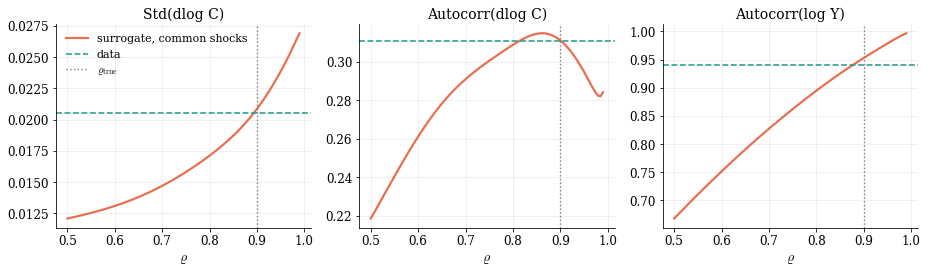

In [6]:
def simulate_paths(consumption, rho_values, T, seed, burn=200, K0=K_STAR):
    """Simulate one path per candidate rho under one common shock sequence.
    `consumption(logz, K, rho)` returns C for arrays; returns Y, C, K of shape (T, n)."""
    rho = np.asarray(rho_values, float)
    eps = np.random.default_rng(seed).standard_normal(T + burn)
    logz, K = np.zeros_like(rho), np.full_like(rho, K0)
    Y_out, C_out, K_out = [], [], []
    for t in range(T + burn):
        Y = np.exp(logz) * K**bm.ALPHA
        C = consumption(logz, K, rho)
        if t >= burn:
            Y_out.append(Y); C_out.append(C); K_out.append(K)
        K = Y + (1.0 - bm.DELTA) * K - C
        logz = rho * logz + bm.SIGMA * eps[t]
    return np.array(Y_out), np.array(C_out), np.array(K_out)


def moments_surrogate(rho_values, seed=SEED + 1):
    return np.atleast_2d(bm.moments(*simulate_paths(surrogate_consumption, rho_values, T_SIM, seed)))


rho_grid = np.round(np.arange(RHO_LO, RHO_HI + 1e-9, 0.005), 3)
t0 = time.perf_counter()
m_grid = moments_surrogate(rho_grid)
print(f"{len(rho_grid)} candidates simulated in {time.perf_counter()-t0:.1f} s")

# Slope of each moment at the truth, per unit of rho, by central differences on the grid.
i_true = int(np.argmin(np.abs(rho_grid - RHO_TRUE)))
slope = (m_grid[i_true + 1] - m_grid[i_true - 1]) / (rho_grid[i_true + 1] - rho_grid[i_true - 1])
for name, sl, u in zip(bm.MOMENT_NAMES, slope, USED):
    print(f"{name:<20s} moves by {sl:+.4f} per unit of rho at 0.90   {'used' if u else 'diagnostic, not used'}")

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
for ax, j in zip(axes, np.where(USED)[0]):
    ax.plot(rho_grid, m_grid[:, j], color=C_SUR, lw=2.2, label="surrogate, common shocks")
    ax.axhline(m_data[j], color=C_DATA, ls="--", lw=1.6, label="data")
    ax.axvline(RHO_TRUE, color="0.5", ls=":", lw=1.4, label=r"$\varrho_{\rm true}$")
    ax.set_title(bm.MOMENT_NAMES[j], fontsize=14); ax.set_xlabel(r"$\varrho$", fontsize=14); ax.tick_params(labelsize=12)
axes[0].legend(frameon=False, fontsize=11)
fig.tight_layout(); savefig(fig, "smm1_moments"); plt.show()

---
## 5. The criterion and the estimate

$$Q(\varrho) = \big[m(\varrho) - \hat m\big]^\top W \big[m(\varrho) - \hat m\big], \qquad W = I,$$

on the three used moments. The grid gives the picture and a starting point; a bounded scalar
minimizer refines it, calling the surrogate simulation at every trial value. For comparison the
criterion is also evaluated with the reference solver on a coarse grid, one solve per point: the
surrogate's criterion should lie on top of it.

grid minimum at 0.880; refined estimate rho_hat = 0.8793  (truth 0.90, interior: True)
Q(rho_hat) = 9.89e-06

moment                    data    fitted
Std(dlog C)           +0.02049  +0.01987   used
Autocorr(dlog C)      +0.31090  +0.31393   used
Autocorr(log Y)       +0.94102  +0.94157   used
Mean savings rate     +0.25347  +0.25298   diagnostic



reference criterion on 8 points: 19 s, against 99 surrogate points above


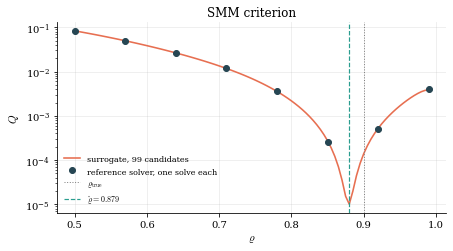

In [7]:
def criterion(rho, moments_fn=moments_surrogate):
    d = moments_fn(np.atleast_1d(rho))[:, USED] - m_data[USED]
    return np.sum(d * d, axis=1)

Q_grid = criterion(rho_grid)
rho_start = rho_grid[np.argmin(Q_grid)]
res = minimize_scalar(lambda r: criterion(r)[0], bounds=(max(RHO_LO, rho_start - 0.02), min(RHO_HI, rho_start + 0.02)),
                      method="bounded", options={"xatol": 1e-5})
rho_hat = res.x
m_hat = moments_surrogate([rho_hat])[0]

print(f"grid minimum at {rho_start:.3f}; refined estimate rho_hat = {rho_hat:.4f}  (truth 0.90, interior: {RHO_LO < rho_hat < RHO_HI})")
print(f"Q(rho_hat) = {res.fun:.2e}\n")
print(f"{'moment':<20s} {'data':>9s} {'fitted':>9s}")
for name, d, f, u in zip(bm.MOMENT_NAMES, m_data, m_hat, USED):
    print(f"{name:<20s} {d:>+9.5f} {f:>+9.5f}   {'used' if u else 'diagnostic'}")

# The same criterion with the reference solver on a coarse grid (one solve per point).
rho_coarse = np.round(np.arange(RHO_LO, RHO_HI + 1e-9, 0.07), 3)
t0 = time.perf_counter()
m_ref = []
for rho in rho_coarse:
    pol = bm.solve(BETA, rho)
    Y, C, K = simulate_paths(lambda lz, K_, r: pol.consumption(np.exp(lz), bm.cash_on_hand(np.exp(lz), K_)), [rho], T_SIM, SEED + 1)
    m_ref.append(bm.moments(Y, C, K))
m_ref = np.array(m_ref)
Q_ref = np.sum((m_ref[:, USED] - m_data[USED])**2, axis=1)
print(f"\nreference criterion on {len(rho_coarse)} points: {time.perf_counter()-t0:.0f} s, against {len(rho_grid)} surrogate points above")

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.semilogy(rho_grid, Q_grid, color=C_SUR, lw=1.6, label="surrogate, 99 candidates")
ax.semilogy(rho_coarse, Q_ref, "o", color=C_REF, ms=6, label="reference solver, one solve each")
ax.axvline(RHO_TRUE, color="0.5", ls=":", lw=1, label=r"$\varrho_{\rm true}$")
ax.axvline(rho_hat, color=C_DATA, ls="--", lw=1.2, label=rf"$\hat\varrho = {rho_hat:.3f}$")
ax.set_xlabel(r"$\varrho$"); ax.set_ylabel("$Q$"); ax.set_title("SMM criterion"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); savefig(fig, "smm1_criterion"); plt.show()

---
## 6. The other route: a Gaussian process of the moment map

The network above is a surrogate of the model's *policy*; the moments are simulated from it at
every candidate. The other kind of surrogate from Session 6 fits the *moment map* itself:
$m_j(\varrho)$, one Gaussian process per moment, on a handful of reference solves. The eight
solves of the previous cell are the design. The GP's posterior mean replaces the simulation in the
criterion, and its posterior standard deviation says how far to trust it between the design points.

GP route: 8 reference solves, rho_hat = 0.8784   (network route 0.8793, truth 0.90)
GP posterior sd of the used moments at rho_hat: 2.8e-05, 3.1e-04, 2.3e-05   against sampling sd of the data moments 7.3e-04, 5.1e-02, 1.3e-02


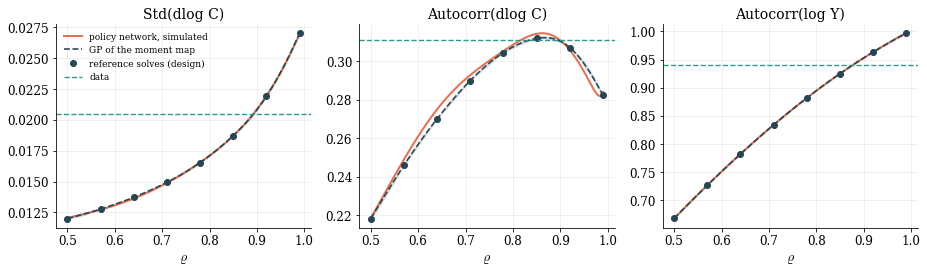

In [8]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern

u = lambda r: (np.atleast_1d(r) - RHO_LO) / (RHO_HI - RHO_LO)          # rho scaled to [0, 1]
gps = []
for j in range(4):
    gp = GaussianProcessRegressor(ConstantKernel(1.0) * Matern(0.3, nu=2.5), alpha=1e-8, normalize_y=True,
                                  n_restarts_optimizer=5, random_state=SEED)
    gps.append(gp.fit(u(rho_coarse)[:, None], m_ref[:, j]))

def moments_gp(rho_values, return_std=False):
    out = [gp.predict(u(rho_values)[:, None], return_std=True) for gp in gps]
    mean = np.column_stack([o[0] for o in out]); std = np.column_stack([o[1] for o in out])
    return (mean, std) if return_std else mean

Q_gp = criterion(rho_grid, moments_gp)
res_gp = minimize_scalar(lambda r: criterion(r, moments_gp)[0],
                         bounds=(max(RHO_LO, rho_grid[np.argmin(Q_gp)] - 0.02), min(RHO_HI, rho_grid[np.argmin(Q_gp)] + 0.02)),
                         method="bounded", options={"xatol": 1e-5})
rho_hat_gp = res_gp.x
_, sd_at_hat = moments_gp([rho_hat_gp], return_std=True)
print(f"GP route: {len(rho_coarse)} reference solves, rho_hat = {rho_hat_gp:.4f}   (network route {rho_hat:.4f}, truth 0.90)")
print("GP posterior sd of the used moments at rho_hat: " + ", ".join(f"{v:.1e}" for v in sd_at_hat[0, USED])
      + "   against sampling sd of the data moments " + ", ".join(f"{v:.1e}" for v in m_draws.std(0)[USED]))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
mg, sg = moments_gp(rho_grid, return_std=True)
for ax, j in zip(axes, np.where(USED)[0]):
    ax.plot(rho_grid, m_grid[:, j], color=C_SUR, lw=2.0, label="policy network, simulated")
    ax.plot(rho_grid, mg[:, j], color=C_REF, lw=1.6, ls="--", label="GP of the moment map")
    ax.fill_between(rho_grid, mg[:, j] - 2 * sg[:, j], mg[:, j] + 2 * sg[:, j], color=C_REF, alpha=0.15)
    ax.plot(rho_coarse, m_ref[:, j], "o", color=C_REF, ms=6, label="reference solves (design)")
    ax.axhline(m_data[j], color=C_DATA, ls="--", lw=1.4, label="data")
    ax.set_title(bm.MOMENT_NAMES[j], fontsize=14); ax.set_xlabel(r"$\varrho$", fontsize=14); ax.tick_params(labelsize=12)
axes[0].legend(frameon=False, fontsize=9)
fig.tight_layout(); savefig(fig, "smm1_gp_route"); plt.show()

The estimate is close to 0.90 but not equal to it, for two reasons that the figure separates.
The observed sample has 500 periods, so its moments differ from the model's population moments: the
reference solver's own criterion, evaluated at the truth with the estimation's shocks, is not zero
either. And the surrogate is not the model: its consumption error at each $\varrho$ (Section 3) moves
the simulated moments by a small amount. The gap between the two curves in the figure is the
second effect; the position of the minimum relative to 0.90 is mostly the first.

## 7. What to remember

1. **A surrogate with the parameter as an input replaces the solve inside the loop.** Training
   costs seconds once; afterwards every candidate $\varrho$ is one simulation, and the whole
   criterion can be drawn.
2. **Check the surrogate where the estimator uses it.** The Euler residual is the training loss;
   the consumption error against a reference solution, on the ergodic set and across the parameter
   range, is the number to report.
3. **Common random numbers** turn the simulated moments into a smooth function. Without them the
   optimizer chases noise.
4. **Read the criterion, not only its argmin.** A clean interior minimum with steep sides is what
   identification looks like; a flat stretch is the first thing to look for in Notebook 2.
5. **Two surrogates, one estimate.** The policy network answers any $\varrho$ after one training
   run; the GP of the moment map answers after a handful of solves and carries an error bar. With
   one parameter both routes land on the same estimate; the GP route is the cheaper one here.

In [9]:
ok = (RHO_LO < rho_hat < RHO_HI) and abs(rho_hat - RHO_TRUE) < 0.03 and all(r[3] < 5e-3 for r in acc) and abs(rho_hat_gp - rho_hat) < 0.02
print(("PASS" if ok else "CHECK") + f": rho_hat = {rho_hat:.4f} (network), {rho_hat_gp:.4f} (GP), max mean consumption error {max(r[3] for r in acc):.1e}")
print(f"RUN_MODE = {RUN_MODE}; notebook wall-clock {time.perf_counter()-T_NOTEBOOK:.0f} s")

PASS: rho_hat = 0.8793 (network), 0.8784 (GP), max mean consumption error 1.1e-03
RUN_MODE = teaching; notebook wall-clock 208 s
